In [1]:
import pandas as pd
import numpy as np
import sys
import os

import matplotlib.pyplot as plt


In [2]:
train_data = pd.read_csv(os.path.join('datasets', 'flextrack_phase1_train.csv'))
display(train_data.head())
train_data.describe(include='all')

,Site,Timestamp_Local,Dry_Bulb_Temperature_C,Global_Horizontal_Radiation_W/m2,Building_Power_kW,Demand_Response_Flag,Demand_Response_Capacity_kW
0,siteA,2019-01-01 00:00:00,22.20,0.0,4.8,0,0.0
1,siteA,2019-01-01 00:15:00,22.27,0.0,4.8,0,0.0
2,siteA,2019-01-01 00:30:00,22.35,0.0,4.8,0,0.0
3,siteA,2019-01-01 00:45:00,22.42,0.0,4.8,0,0.0
4,siteA,2019-01-01 01:00:00,22.50,0.0,4.8,0,0.0


,Site,Timestamp_Local,Dry_Bulb_Temperature_C,Global_Horizontal_Radiation_W/m2,Building_Power_kW,Demand_Response_Flag,Demand_Response_Capacity_kW
count,105120,105120,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000
unique,3,70080,NaN,NaN,NaN,NaN,NaN
top,siteA,2019-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN
freq,35040,2,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,17.667216,252.487253,53.951255,-0.013461,-0.081719
std,NaN,NaN,5.443964,333.386623,95.952124,0.171449,4.429414
min,NaN,NaN,2.400000,0.000000,0.400000,-1.000000,-129.420000
25%,NaN,NaN,13.500000,0.000000,4.800000,0.000000,0.000000
50%,NaN,NaN,17.570000,18.000000,5.590000,0.000000,0.000000
75%,NaN,NaN,21.350000,489.000000,56.330000,0.000000,0.000000


In [3]:
# Examine target variables, looks like a three-classes classification problem
print(train_data['Demand_Response_Flag'].unique())

[ 0  1 -1]


<Axes: >

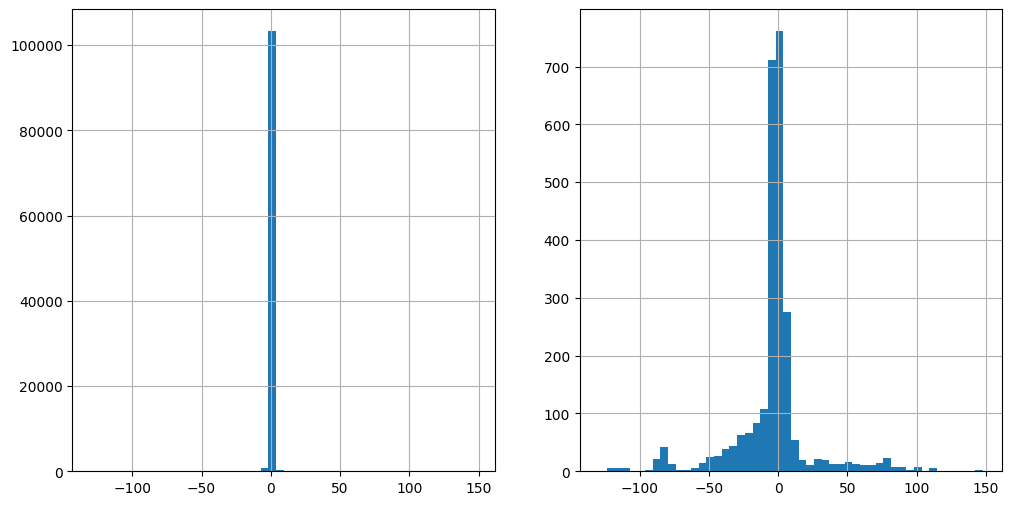

In [4]:
# Distribution of regression target variable: 'Demand_Response_Capacity_kW'
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,6))
train_data['Demand_Response_Capacity_kW'].hist(bins=50, ax=ax1)
train_data[train_data['Demand_Response_Capacity_kW']!=0]['Demand_Response_Capacity_kW'].hist(bins=50, ax=ax2)

<Axes: >

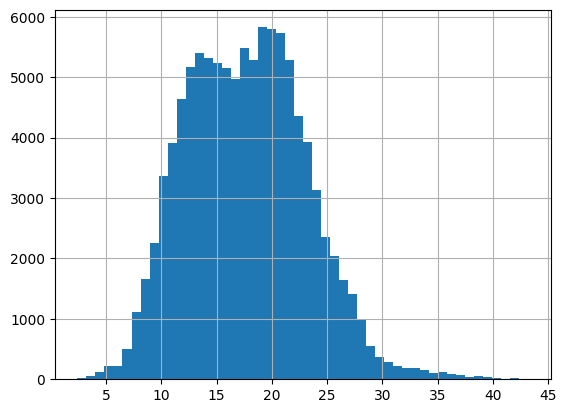

In [5]:
# distribution of 'Dry_Bulb_Temperature_C'
train_data['Dry_Bulb_Temperature_C'].hist(bins=50)

<Axes: >

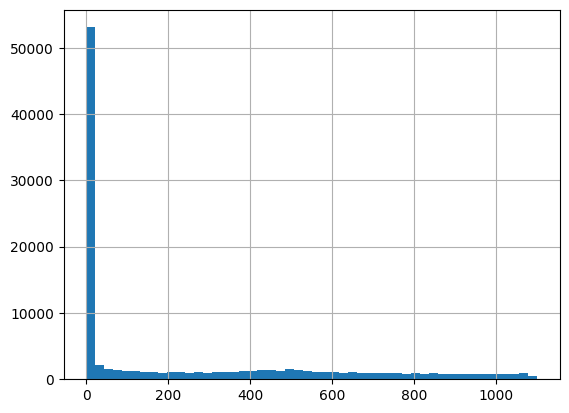

In [6]:
# Distribution of 'Global_Horizontal_Radiation_W/m2'
train_data['Global_Horizontal_Radiation_W/m2'].hist(bins=50)

<Axes: >

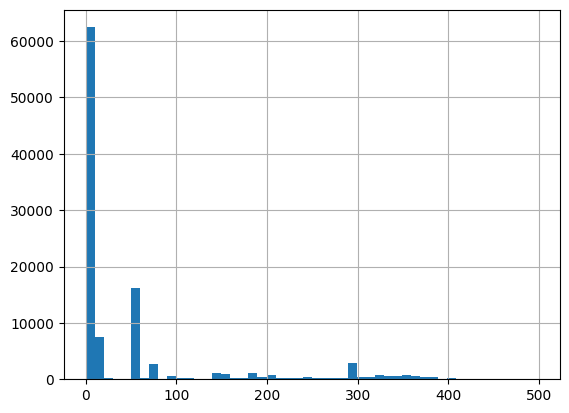

In [7]:
# Distribution of 'Building_Power_kW'
train_data['Building_Power_kW'].hist(bins=50)

In [8]:
train_data[['Demand_Response_Capacity_kW','Building_Power_kW']].corr()

,Demand_Response_Capacity_kW,Building_Power_kW
Demand_Response_Capacity_kW,1.000000,-0.012825
Building_Power_kW,-0.012825,1.000000


In [9]:
df = train_data[
    train_data['Demand_Response_Flag'] != 0
].copy(deep=True)
df = df[['Demand_Response_Flag','Demand_Response_Capacity_kW']].copy(deep=True)
condition = df['Demand_Response_Capacity_kW'].abs() > 1
df['DRC_values_flg'] = np.where(condition, 1, 0)
df.groupby('DRC_values_flg')['Demand_Response_Flag'].count()

DRC_values_flg
0     898
1    2211
Name: Demand_Response_Flag, dtype: int64

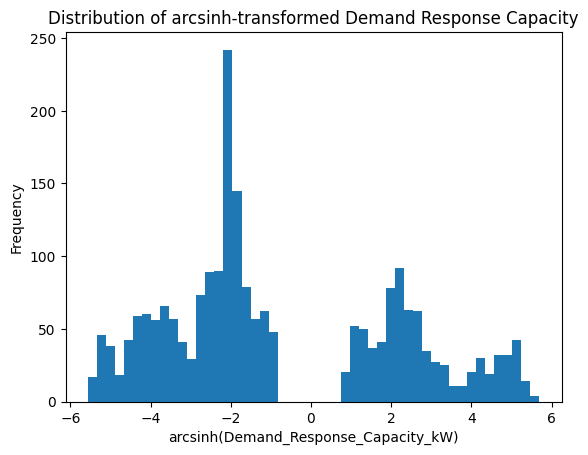

In [10]:
y = np.arcsinh(df[condition]['Demand_Response_Capacity_kW'].values)
plt.hist(y, bins=50)
plt.xlabel('arcsinh(Demand_Response_Capacity_kW)')
plt.ylabel('Frequency')
plt.title('Distribution of arcsinh-transformed Demand Response Capacity')
plt.show()

### Investigate some submissions data

In [13]:
train_data_zero = train_data[train_data['Demand_Response_Flag'] == 0].copy(deep=True)
train_data_neg  = train_data[train_data['Demand_Response_Flag'] == -1].copy(deep=True)
train_data_pos  = train_data[train_data['Demand_Response_Flag'] == 1].copy(deep=True)

<Axes: >

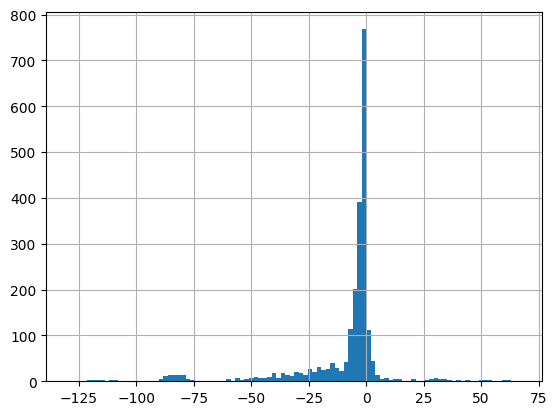

In [18]:
train_data_neg['Demand_Response_Capacity_kW'].hist(bins=100)

<Axes: >

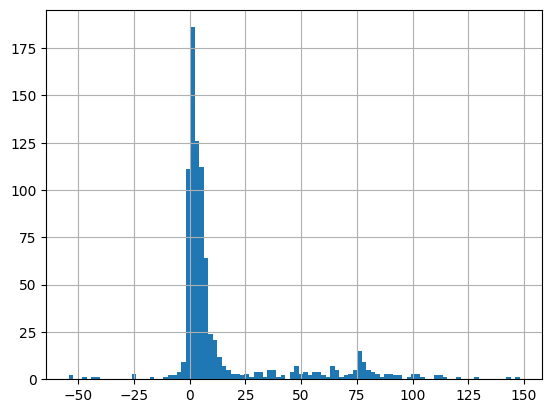

In [17]:
train_data_pos['Demand_Response_Capacity_kW'].hist(bins=100)